## Retail Sales Project**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("C:\\My study\\python\\retail sales project\\data\\data.csv",encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.isnull().sum()
df=df.dropna()

In [ ]:
df.isnull().sum()
df.dtypes
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

## **Feature Engineering**

In [ ]:
df["total_sales"]=df["UnitPrice"]*df["Quantity"]
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df["year"]=df["InvoiceDate"].dt.year
df["day"]=df["InvoiceDate"].dt.day_name()
df["hour"]=df["InvoiceDate"].dt.hour
df["month"]=df["InvoiceDate"].dt.month_name()
df["month"]=pd.Categorical(df["month"],categories=["January","February","March","April","May","June","July","August","September","Octobor","November","December"],ordered=True)
df=df.sort_values("month")
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_sales,year,day,hour,month
55310,540986,48188,DOORMAT WELCOME PUPPIES,2,2011-01-12 16:14:00,7.95,15291.0,United Kingdom,15.90,2011,Wednesday,16,January
44945,540247,48188,DOORMAT WELCOME PUPPIES,1,2011-01-05 15:56:00,7.95,15464.0,United Kingdom,7.95,2011,Wednesday,15,January
44946,540247,20685,DOORMAT RED RETROSPOT,1,2011-01-05 15:56:00,7.95,15464.0,United Kingdom,7.95,2011,Wednesday,15,January
44947,540247,21896,POTTING SHED TWINE,3,2011-01-05 15:56:00,2.10,15464.0,United Kingdom,6.30,2011,Wednesday,15,January
44948,540247,22258,FELT FARM ANIMAL RABBIT,2,2011-01-05 15:56:00,1.25,15464.0,United Kingdom,2.50,2011,Wednesday,15,January


## **Exploratory Data Analysis (EDA)**

In [3]:
# Sales Overview
print("Total_orders",":",df["InvoiceNo"].nunique())
print("Total_sales",":",df["total_sales"].sum())
print("Total_customer",":",df["CustomerID"].nunique())
print("Total_product",":",df["StockCode"].nunique())

NameError: name 'df' is not defined

Monthly sales Trand

C:\Users\user\AppData\Local\Temp\ipykernel_16676\3480216625.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("month", as_index=False)["total_sales"].sum().reset_index(drop=True)


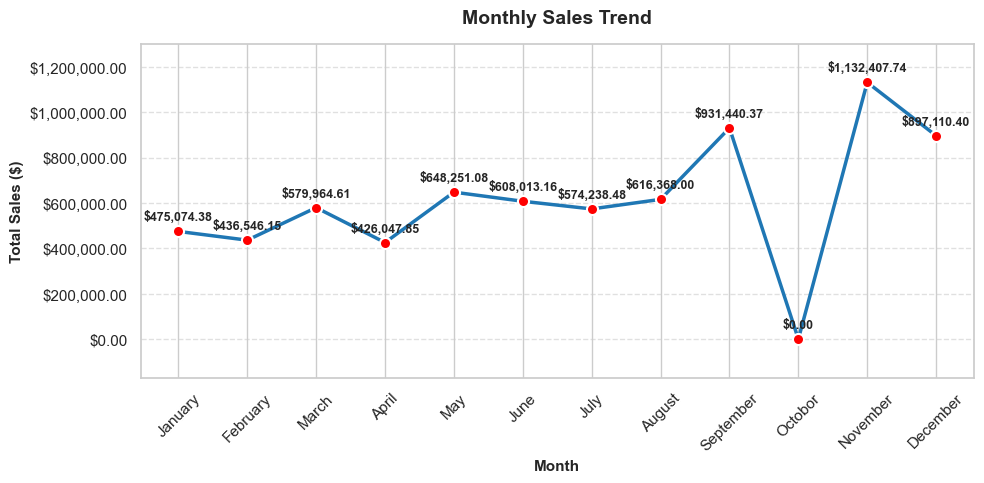

In [ ]:
import matplotlib.ticker as ticker
# 1. Aggregate data: Sum total sales by month
df_monthly = (
    df.groupby("month", as_index=False)["total_sales"].sum().reset_index(drop=True)
)

# 2. Set theme and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 3. Create the line plot
ax = sns.lineplot(
    data=df_monthly,
    x="month",
    y="total_sales",
    errorbar=None,
    color="#1f77b4",
    linewidth=2.5,
    marker="o",
    markersize=8,
    markerfacecolor="red",
    markeredgecolor="white",
    markeredgewidth=1.5,
)

# 4. Add data labels above each point
for idx, row in df_monthly.iterrows():
    ax.annotate(
        f"${row['total_sales']:,.2f}",
        (idx, row["total_sales"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

# 5. Add title and axis labels
plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Month", fontsize=11, fontweight="bold")
plt.ylabel("Total Sales ($)", fontsize=11, fontweight="bold")

# 6. Zoom in Y-axis to highlight trend variations for small sales values
y_min = df_monthly["total_sales"].min()
y_max = df_monthly["total_sales"].max()
padding = (y_max - y_min) * 0.15 if (y_max - y_min) > 0 else 1

plt.ylim(y_min - padding, y_max + padding)

# 7. Format Y-axis labels
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.2f}"))
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The monthly sales trend indicates a generally upward trajectory throughout the year, with stable sales during the middle months and exceptional performance in the final quarter. November recorded the highest sales ($1.13M), followed by September ($931K). October shows zero sales, which likely reflects missing or incorrect data rather than actual business performance and should be investigated. Overall, the business demonstrated strong year-end growth, suggesting successful seasonal demand or promotional activities.

Monthly orders

C:\Users\user\AppData\Local\Temp\ipykernel_16676\362768418.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("month")["InvoiceNo"]
C:\Users\user\AppData\Local\Temp\ipykernel_16676\362768418.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


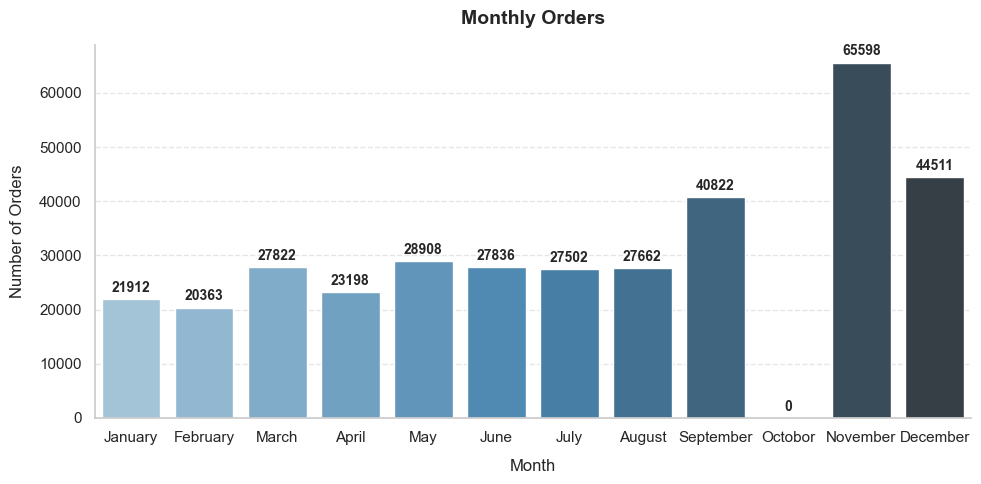

In [ ]:
monthly_orders = (
    df.groupby("month")["InvoiceNo"]
      .count()
      .reset_index(name="order_count")
)
fig, ax = plt.subplots(figsize=(10, 5))

# Plot
sns.barplot(
    data=monthly_orders,
    x='month',
    y='order_count',
    palette='Blues_d',
    ax=ax
)

# Add value labels on top of bars
#ax.bar_label(ax.containers[0], padding=3, fmt='%d', fontsize=10, fontweight='bold')
for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fmt="%d",
        fontsize=10,
        fontweight="bold"
    )
# Titles and labels
ax.set_title('Monthly Orders', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12, labelpad=10)
ax.set_ylabel('Number of Orders', fontsize=12, labelpad=10)

# Clean grid & spines
sns.despine()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

The monthly order trend demonstrates consistent business growth throughout the year, with relatively stable order volumes during the middle months and exceptional performance in the final quarter. November recorded the highest number of orders (65,598), followed by December (44,511). A sharp increase in September indicates a period of strong customer demand, while October shows zero orders, which likely reflects missing or incorrect data rather than actual business performance. Overall, the company experienced robust year-end growth, supported by significantly higher order volumes in Q4.

top 10 selling product

In [ ]:
top_10_product=df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_10_product

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_16676\726212048.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


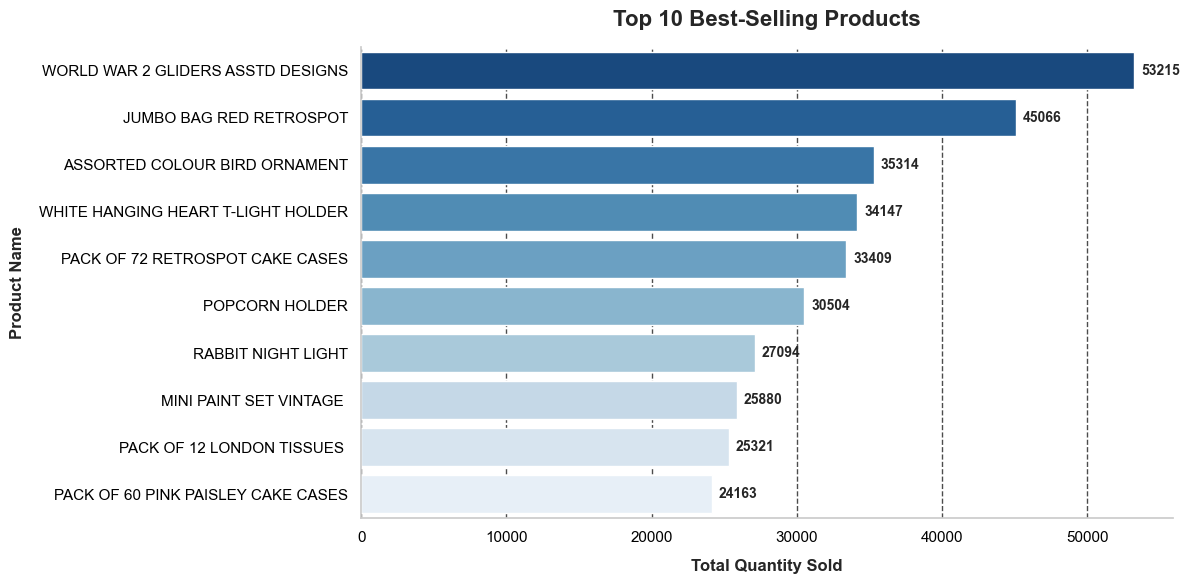

In [ ]:


# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot
sns.barplot(
    x=top_10_product.values,
    y=top_10_product.index,
    palette="Blues_r",
    ax=ax
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

# Title and labels
ax.set_title(
    "Top 10 Best-Selling Products",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Total Quantity Sold",
    fontsize=12,
    labelpad=10,fontweight="bold"
)

ax.set_ylabel(
    "Product Name",
    fontsize=12,
    labelpad=10,fontweight="bold"
)

plt.xticks(color="black")
plt.yticks(color="black")

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.7,color="black")

# Remove top and right border
sns.despine()

plt.tight_layout()
plt.show()

The top-selling products analysis reveals that WORLD WAR 2 GLIDERS ASSTD DESIGNS is the highest-selling product with 53,215 units sold, followed by JUMBO BAG RED RETROSPOT with 45,066 units. Home décor, gift items, and household accessories dominate the list, indicating strong customer preference for these categories. Although sales gradually decline across the rankings, all top 10 products recorded more than 24,000 units sold, demonstrating a strong and well-balanced product portfolio with consistently high demand.

Top 10 Customer

In [ ]:
top_10_customer=df.groupby("CustomerID")["total_sales"].sum().sort_values(ascending=False).head(10)
top_10_customer

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: total_sales, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_16676\57958463.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


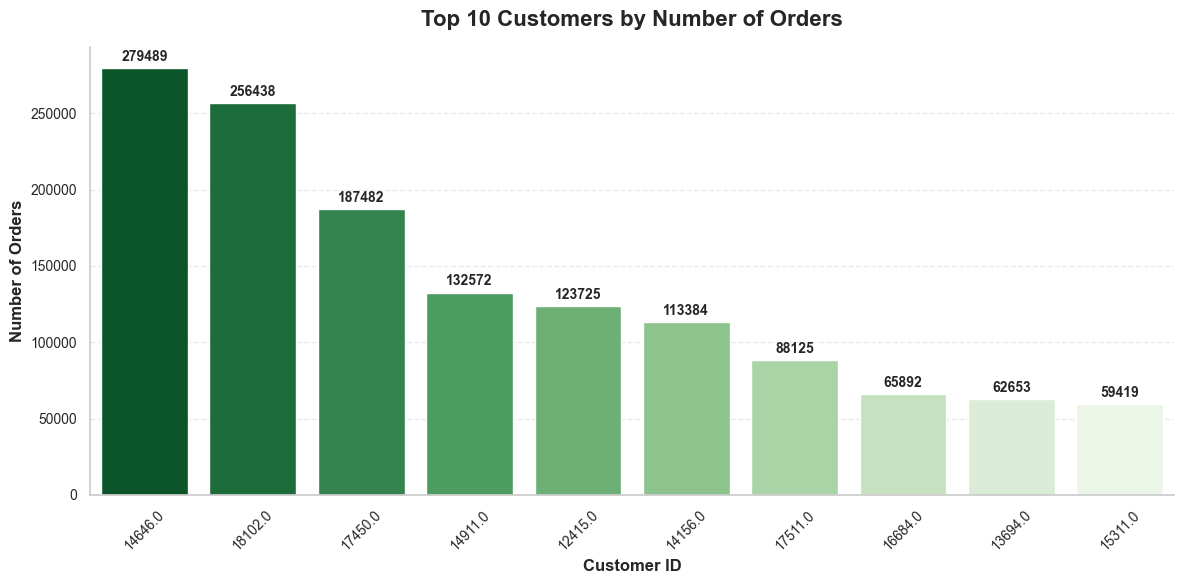

In [ ]:
# Create Figure
fig, ax = plt.subplots(figsize=(12, 6))

# Color palette
colors = sns.color_palette("Greens_r", len(top_10_customer))

# Bar Plot
sns.barplot(
    x=top_10_customer.index.astype(str),   # Customer ID
    y=top_10_customer.values,              # Order Count
    palette=colors,
    ax=ax
)

# Value Labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Top 10 Customers by Number of Orders",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Axis Labels
ax.set_xlabel(
    "Customer ID",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Orders",
    fontsize=12,
    fontweight="bold"
)

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Remove unnecessary borders
sns.despine()

# Tick styling
ax.tick_params(axis="x", labelsize=10, rotation=45)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.show()

The analysis of the top 10 customers by number of orders shows that Customer ID 14646 is the most active customer, placing 279,489 orders, followed by Customer ID 18102 with 256,438 orders. The top two customers contribute significantly more orders than the rest, indicating that a small group of loyal customers drives a substantial share of business activity. Order volumes decline steadily across the rankings, with the tenth-ranked customer recording 59,419 orders.

Top countries

In [ ]:
countries=top_10_countires.reset_index()
countries["sales%"]=countries["total_sales"]/df["total_sales"].sum()*100
countries

,Country,total_sales,sales%
0,United Kingdom,6767873.394,81.539997
1,Netherlands,284661.540,3.429630
2,EIRE,250285.220,3.015461
3,Germany,221698.210,2.671042
4,France,196712.840,2.370015
5,Australia,137077.270,1.651520
6,Switzerland,55739.400,0.671554
7,Spain,54774.580,0.659929
8,Belgium,40910.960,0.492899
9,Sweden,36595.910,0.440911


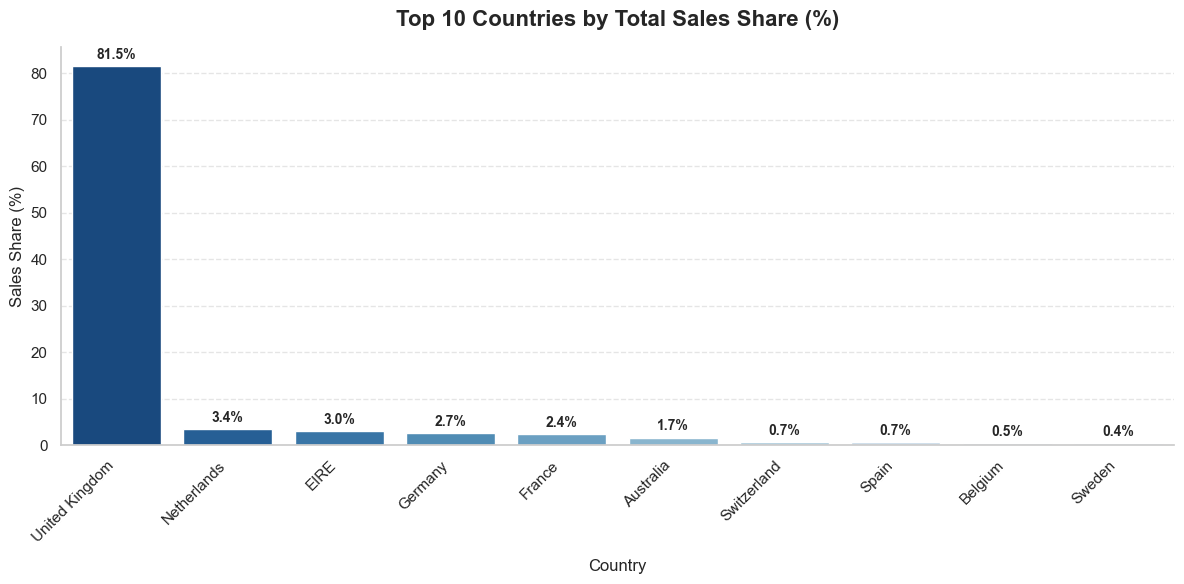

In [ ]:

plt.figure(figsize=(12, 6))


ax = sns.barplot(
    data=countries, 
    x="Country", 
    y="sales%", 
    palette="Blues_r",  
    hue="Country", 
    legend=False
)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',                      
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=10, fontweight='bold', 
            xytext=(0, 3), textcoords='offset points'
        )


plt.xticks(rotation=45, ha='right', fontsize=11)


plt.title("Top 10 Countries by Total Sales Share (%)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Country", fontsize=12, labelpad=10)
plt.ylabel("Sales Share (%)", fontsize=12)


sns.despine()              
plt.grid(axis='y', linestyle='--', alpha=0.5) 

plt.tight_layout() 
plt.show()

The country-wise sales analysis reveals that the United Kingdom is the company's dominant market, contributing 81.5% of total sales. The Netherlands (3.4%), EIRE (3.0%), Germany (2.7%), and France (2.4%) are the leading international markets, while the remaining countries each account for less than 2% of total sales.

In [ ]:
top_10_countires=df.groupby("Country")["total_sales"].sum().sort_values(ascending=False).head(10)
top_10_countires

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: total_sales, dtype: float64

C:\Users\user\AppData\Local\Temp\ipykernel_16676\373437111.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


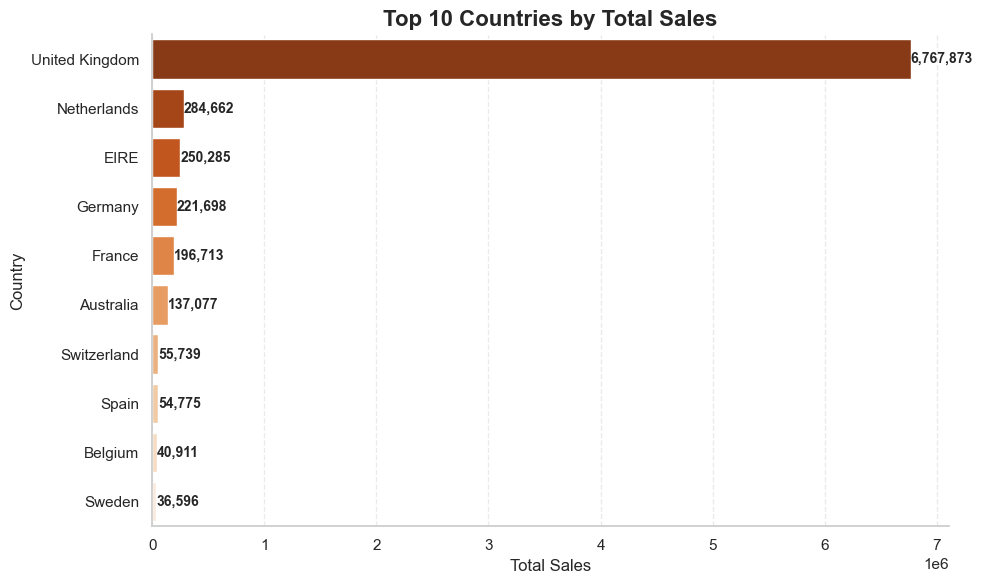

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    x=top_10_countires.values,
    y=top_10_countires.index,
    palette="Oranges_r",
    ax=ax
)

for bar in ax.patches:
    width = bar.get_width()

    ax.text(
        width + 100,                 
        bar.get_y() + bar.get_height()/2,
        f"{width:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Top 10 Countries by Total Sales", fontsize=16, fontweight="bold")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Country")

ax.grid(axis="x", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

The country-wise sales analysis shows that the United Kingdom is the company's dominant market, generating $6.77 million in total sales. The Netherlands ($284.7K), EIRE ($250.3K), Germany ($221.7K), and France ($196.7K) are the leading international contributors, while the remaining countries each account for relatively modest sales. The significant gap between the UK and other markets indicates a high level of revenue concentration. Expanding operations in key international markets could help reduce business risk and support sustainable long-term growth.

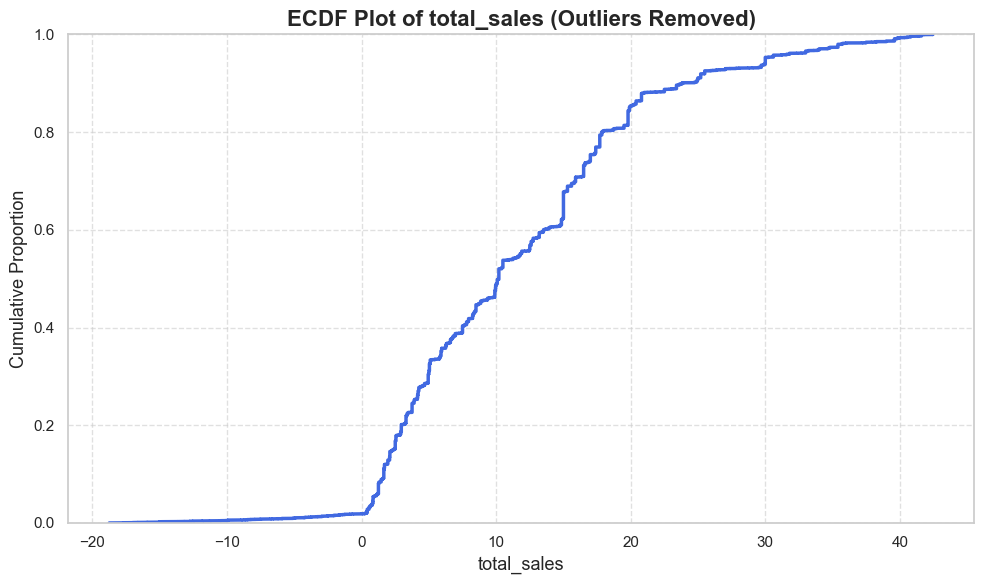

In [ ]:
Q1 = df["total_sales"].quantile(0.25)
Q3 = df["total_sales"].quantile(0.75)
IQR = Q3 - Q1

filtered = df[
    (df["total_sales"] >= Q1 - 1.5*IQR) &
    (df["total_sales"] <= Q3 + 1.5*IQR)
]



plt.figure(figsize=(10, 6))

sns.ecdfplot(
    data=filtered,
    x="total_sales",
    linewidth=2.5,
    color="royalblue"
)

plt.title("ECDF Plot of total_sales (Outliers Removed)", fontsize=16, fontweight="bold")
plt.xlabel("total_sales", fontsize=13)
plt.ylabel("Cumulative Proportion", fontsize=13)

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

Hourly sales trand

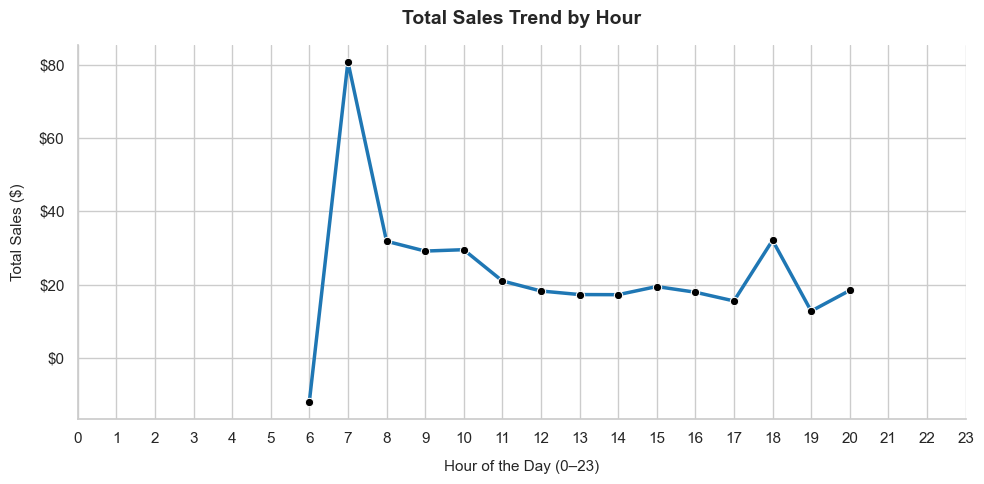

In [ ]:


# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Create figure and axis with a standard widescreen aspect ratio
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the line chart
sns.lineplot(
    data=df,
    x="hour",
    y="total_sales",
    errorbar=None,
    marker="o",  # Add data points
    linewidth=2.5,
    color="#1f77b4",  # Professional blue
    ax=ax,markerfacecolor="black"
)

# Titles and labels
ax.set_title("Total Sales Trend by Hour", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Hour of the Day (0–23)", fontsize=11, labelpad=10)
ax.set_ylabel("Total Sales ($)", fontsize=11, labelpad=10)

# Format axes
ax.set_xticks(range(0, 24))  # Ensure all 24 hours are explicitly displayed
ax.yaxis.set_major_formatter("${x:,.0f}")  # Format Y-axis as currency ($)

# Clean up borders
sns.despine()

plt.tight_layout()
plt.show()

The hourly sales analysis reveals two key sales peaks during the day. The highest average sales occur at 7:00 AM, followed by a secondary peak at 6:00 PM. Sales remain relatively stable throughout the afternoon before declining in the late evening. A negative sales value at 6:00 AM suggests the presence of returns, refunds, or data anomalies and should be investigated. Overall, customer purchasing activity is strongest during the early morning and early evening, 

Distribution of Total Sales by Day

C:\Users\user\AppData\Local\Temp\ipykernel_16676\971700171.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


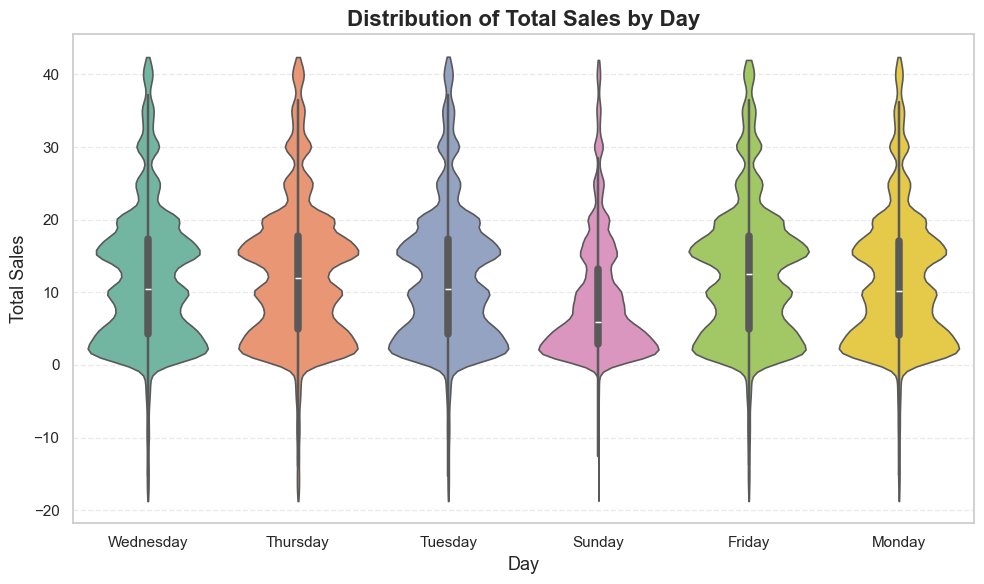

In [ ]:
Q1 = df["total_sales"].quantile(0.25)
Q3 = df["total_sales"].quantile(0.75)
IQR = Q3 - Q1

filtered = df[
    (df["total_sales"] >= Q1 - 1.5*IQR) &
    (df["total_sales"] <= Q3 + 1.5*IQR)
]



plt.figure(figsize=(10, 6))

sns.violinplot(
    data=filtered,
    x="day",
    y="total_sales",
    palette="Set2",
    inner="box",      
    linewidth=1.2,
    cut=0             
)

plt.title("Distribution of Total Sales by Day", fontsize=16, fontweight="bold")
plt.xlabel("Day", fontsize=13)
plt.ylabel("Total Sales", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

The distribution of total sales by day indicates that customer purchasing patterns are generally consistent throughout the week. While Monday and Friday exhibit slightly higher median sales and greater variability, Sunday records comparatively lower sales. High-value transactions occur on all days, and the presence of negative sales values suggests returns or refunds within the dataset. Overall, there is no significant day-of-week effect on sales performance, indicating stable customer demand across the week.

In [ ]:
df0=df1.dropna()

Monthly Total Sales by Day

C:\Users\user\AppData\Local\Temp\ipykernel_16676\1731742042.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df2=df0.pivot_table(index="day",columns="month",values="total_sales")


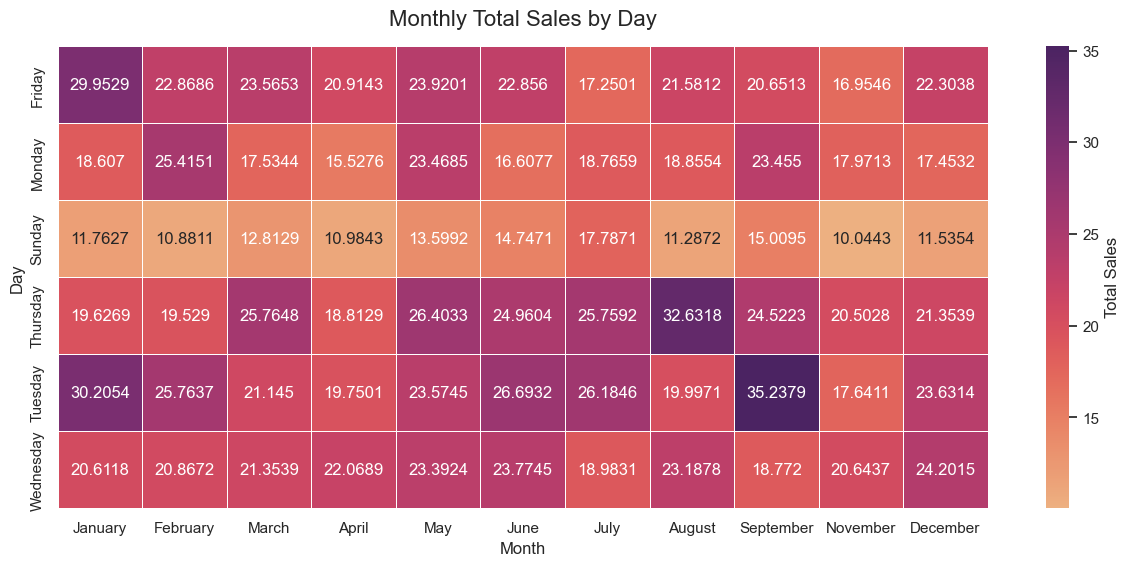

In [ ]:
df0=df[["day","month","total_sales"]]
df2=df0.pivot_table(index="day",columns="month",values="total_sales")



plt.figure(figsize=(15, 6))


sns.heatmap(
    df2, 
    annot=True,           
    fmt="g",              
    cmap="flare",         
    linewidths=0.5,        
    linecolor="white",     
    cbar_kws={'label': 'Total Sales'} 
)


plt.title("Monthly Total Sales by Day", fontsize=16, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Day", fontsize=12)


plt.show()

The heatmap analysis shows that Tuesday is the strongest-performing day of the week, with the highest average sales occurring in September (35.24). Thursday also demonstrates consistently high sales, particularly in August (32.63), while Sunday records the lowest average sales throughout the year. Overall, September emerges as the strongest month for average daily sales, whereas November shows relatively lower transaction values. The results suggest that customer spending is generally higher on weekdays than on weekends, highlighting opportunities to schedule promotions and marketing campaigns during high-performing weekday periods.

**Key Findings**
- 📈 November recorded the highest monthly sales and order volume.  
- The United Kingdom contributed over 81% of total sales.  
- 🛍️ WORLD WAR 2 GLIDERS ASSTD DESIGNS was the best-selling product.  
- 👥 Customer 14646 placed the highest number of orders.  
- 📅 Tuesday and Thursday showed the strongest average sales performance.  
- ⚠️ October contained missing or abnormal sales data that requires further investigation.

**Business Recommendations**
- Expand marketing efforts in high-potential international markets such as the Netherlands, Germany, and France to reduce dependence on the UK market.  
- Maintain sufficient inventory for top-selling products to prevent stock shortages.  
- Develop customer loyalty programs targeting high-value customers.  
- Schedule promotional campaigns during peak sales months and high-performing weekdays.  
- Regularly monitor and clean sales data to identify missing values, refunds, and anomalies.

Thank you for reviewing this project. Feedback and suggestions are always welcome. I'm continuously improving my Data Analytics skills through real-world projects.

In [ ]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_sales,year,day,hour,month
55310,540986,48188,DOORMAT WELCOME PUPPIES,2,2011-01-12 16:14:00,7.95,15291.0,United Kingdom,15.90,2011,Wednesday,16,January
44945,540247,48188,DOORMAT WELCOME PUPPIES,1,2011-01-05 15:56:00,7.95,15464.0,United Kingdom,7.95,2011,Wednesday,15,January
44946,540247,20685,DOORMAT RED RETROSPOT,1,2011-01-05 15:56:00,7.95,15464.0,United Kingdom,7.95,2011,Wednesday,15,January
44947,540247,21896,POTTING SHED TWINE,3,2011-01-05 15:56:00,2.10,15464.0,United Kingdom,6.30,2011,Wednesday,15,January
44948,540247,22258,FELT FARM ANIMAL RABBIT,2,2011-01-05 15:56:00,1.25,15464.0,United Kingdom,2.50,2011,Wednesday,15,January
...,...,...,...,...,...,...,...,...,...,...,...,...,...
431666,573695,23557,LANDMARK FRAME BAKER STREET,2,2011-10-31 17:13:00,12.50,15023.0,United Kingdom,25.00,2011,Monday,17,NaN
431667,573695,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,2011-10-31 17:13:00,2.55,15023.0,United Kingdom,81.60,2011,Monday,17,NaN
431668,573695,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-10-31 17:13:00,9.95,15023.0,United Kingdom,19.90,2011,Monday,17,NaN
431669,573695,23543,WALL ART KEEP CALM,1,2011-10-31 17:13:00,8.25,15023.0,United Kingdom,8.25,2011,Monday,17,NaN
